In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Kiểm tra xem TensorFlow đã sẵn sàng chưa
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
#cung khong can thiet reshape   
x_train.reshape(-1, 28, 28, 1)
x_test.reshape(-1, 28, 28, 1)
#normalize: đưa về giá trị [0,1] cho dễ tính toán
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)
print(x_train)


x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)


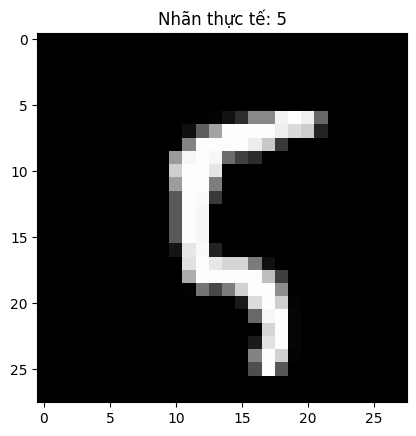

In [4]:
plt.imshow(x_train[100], cmap='gray') 
plt.title(f"Nhãn thực tế: {y_train[100]}") 
plt.show() 

In [9]:
#build model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #Fully connected 
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')

])
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9325 - loss: 0.2237
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9708 - loss: 0.0987
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9775 - loss: 0.0730
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9816 - loss: 0.0600
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9836 - loss: 0.0517


In [6]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9872 - loss: 0.0446


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
so nay kha nang la 7


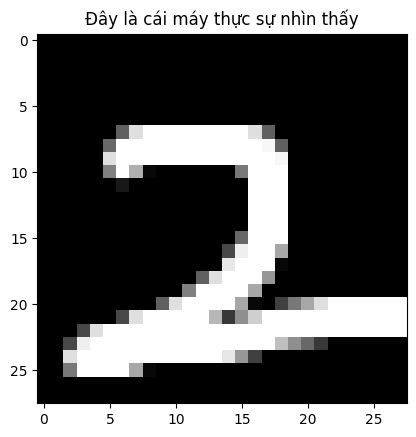

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
so nay kha nang la 7


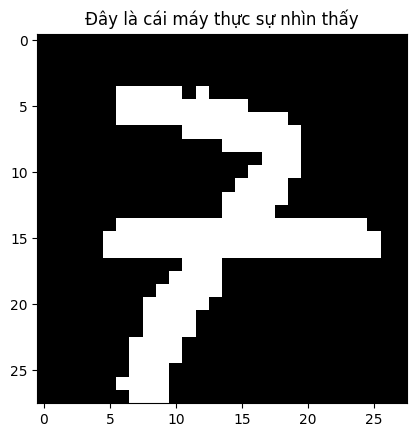

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
so nay kha nang la 6


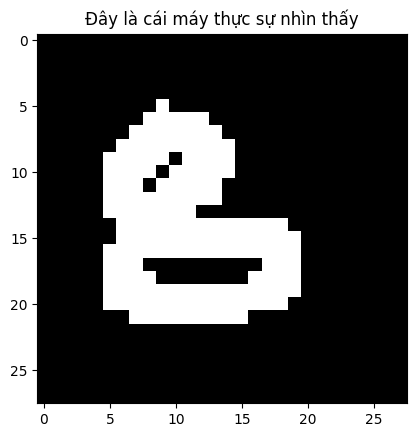

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
so nay kha nang la 2


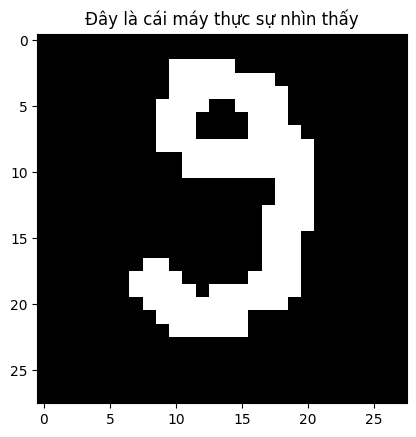

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
so nay kha nang la 6


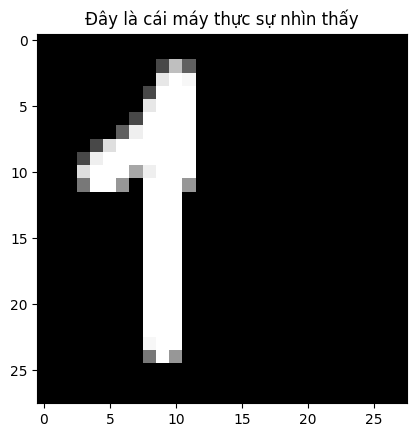

In [10]:
import os
import cv2
i = 1
while os.path.exists(f'img/data{i}.png'):
    img = cv2.imread(f'img/data{i}.png', cv2.IMREAD_GRAYSCALE)
    img = np.invert(np.array(img))
    img = img.astype('float32')/255.0 #normalize
    img = img.reshape(1, 28, 28,  1)
    y_prediction = model.predict(img)
    print(f'so nay kha nang la {np.argmax(y_prediction)}')
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title("Đây là cái máy thực sự nhìn thấy")
    plt.show()
    i+=1
